<a href="https://colab.research.google.com/github/polokocodes/Data-Science---ML-Projects/blob/main/EDA_Loan_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
loan_data = pd.read_csv('/content/loan.csv')
loan_data.head(2)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N


In [3]:
loan_data.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [4]:
loan_data.dtypes

,0
Loan_ID,object
Gender,object
Married,object
Dependents,object
Education,object
Self_Employed,object
ApplicantIncome,int64
CoapplicantIncome,float64
LoanAmount,float64
Loan_Amount_Term,float64


In [5]:
loan_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [6]:
missing_values = loan_data.isnull().sum()

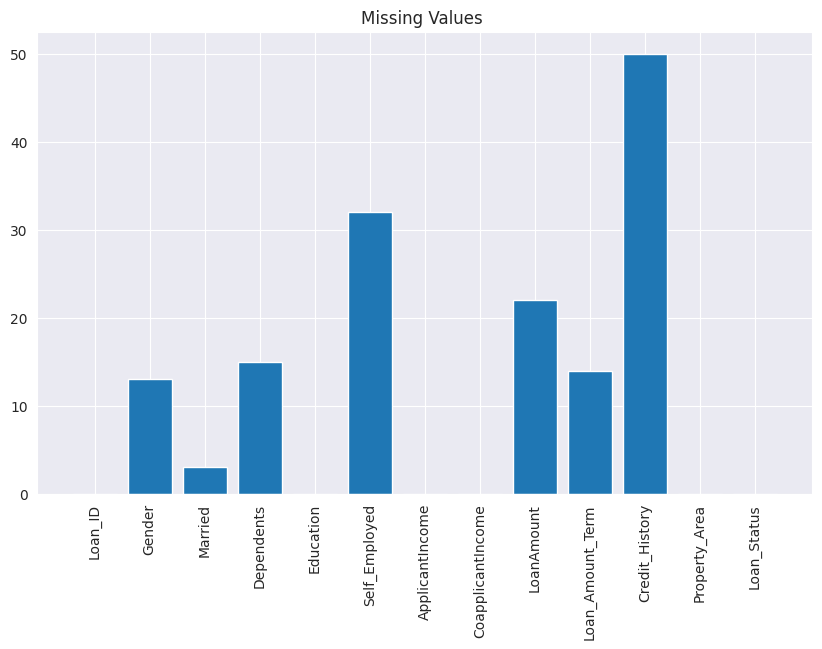

In [7]:
sns.set_style("darkgrid")
plt.figure(figsize=(10, 6))
plt.title('Missing Values ')
plt.bar(missing_values.index, missing_values.values)
plt.xticks(rotation=90)
plt.show()

/tmp/ipykernel_1331/3839200596.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Approved','Denied'])


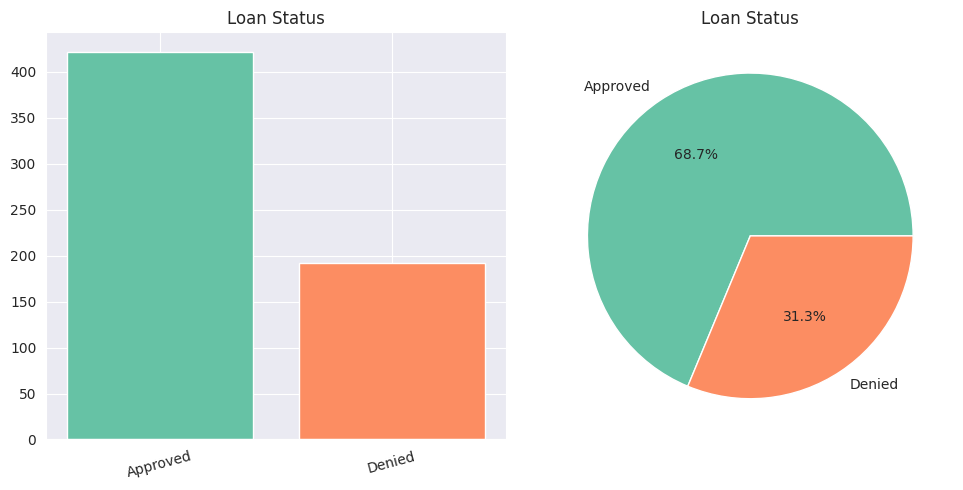

Loan status distribution:68.73%


In [8]:
#Loan Status distribution
fig, axes = plt.subplots(1,2, figsize=(10,5))
axes = axes.flatten()

axes[0].bar(loan_data['Loan_Status'].value_counts().index, loan_data['Loan_Status'].value_counts().values, color=["#66c2a5","#fc8d62"])
axes[0].set_title('Loan Status')
axes[0].set_xticklabels(['Approved','Denied'])
axes[0].tick_params(axis = 'x', rotation = 15)

axes[1].pie(loan_data['Loan_Status'].value_counts(), labels=["Approved","Denied"], autopct="%1.1f%%",
    colors=["#66c2a5","#fc8d62"])
axes[1].set_title('Loan Status')

plt.tight_layout()
plt.show()

loan_distrubution_per = (loan_data['Loan_Status'] == 'Y').mean() *100
print(f"Loan status distribution:{loan_distrubution_per:.2f}%")

In [9]:
# Loan status vs Categorical values
loan_data.dtypes

,0
Loan_ID,object
Gender,object
Married,object
Dependents,object
Education,object
Self_Employed,object
ApplicantIncome,int64
CoapplicantIncome,float64
LoanAmount,float64
Loan_Amount_Term,float64


In [10]:
loan_data['Gender'].head()

,Gender
0,Male
1,Male
2,Male
3,Male
4,Male


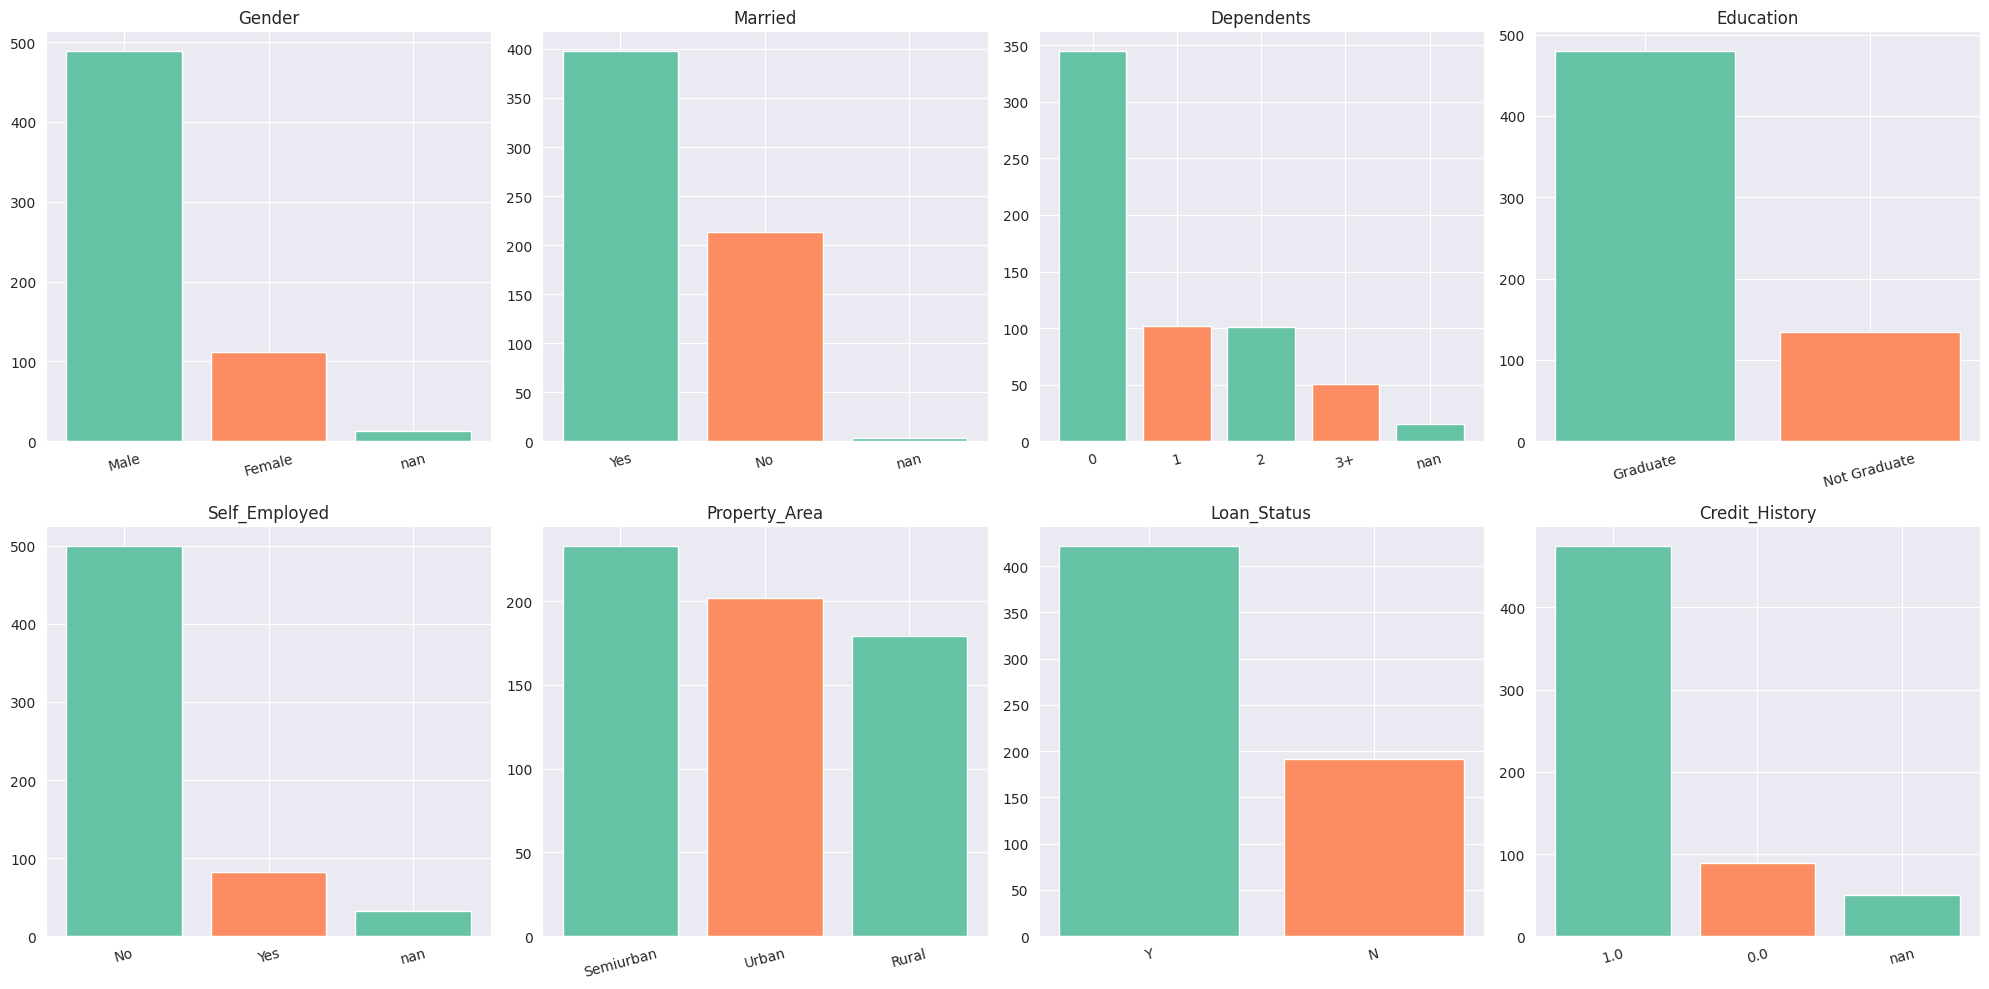

In [11]:
#Categorical features EDA
#Univariate Cartegorical features
cartegorical_features = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status','Credit_History']

fig, axes = plt.subplots(2, 4, figsize=(20,10))
axes = axes.flatten()

for i, col in enumerate(cartegorical_features):
  counts = loan_data[col].value_counts(dropna=False)
  labels = [str(x)for x in counts.index]
  axes[i].bar(labels, counts.values, color = ["#66c2a5","#fc8d62"])
  axes[i].set_title(col)
  axes[i].tick_params(axis='x', rotation=15)
#for j in range(len(cartegorical_features), len(axes)):
 # axes[j].axis('off')

plt.tight_layout()
plt.show()
#


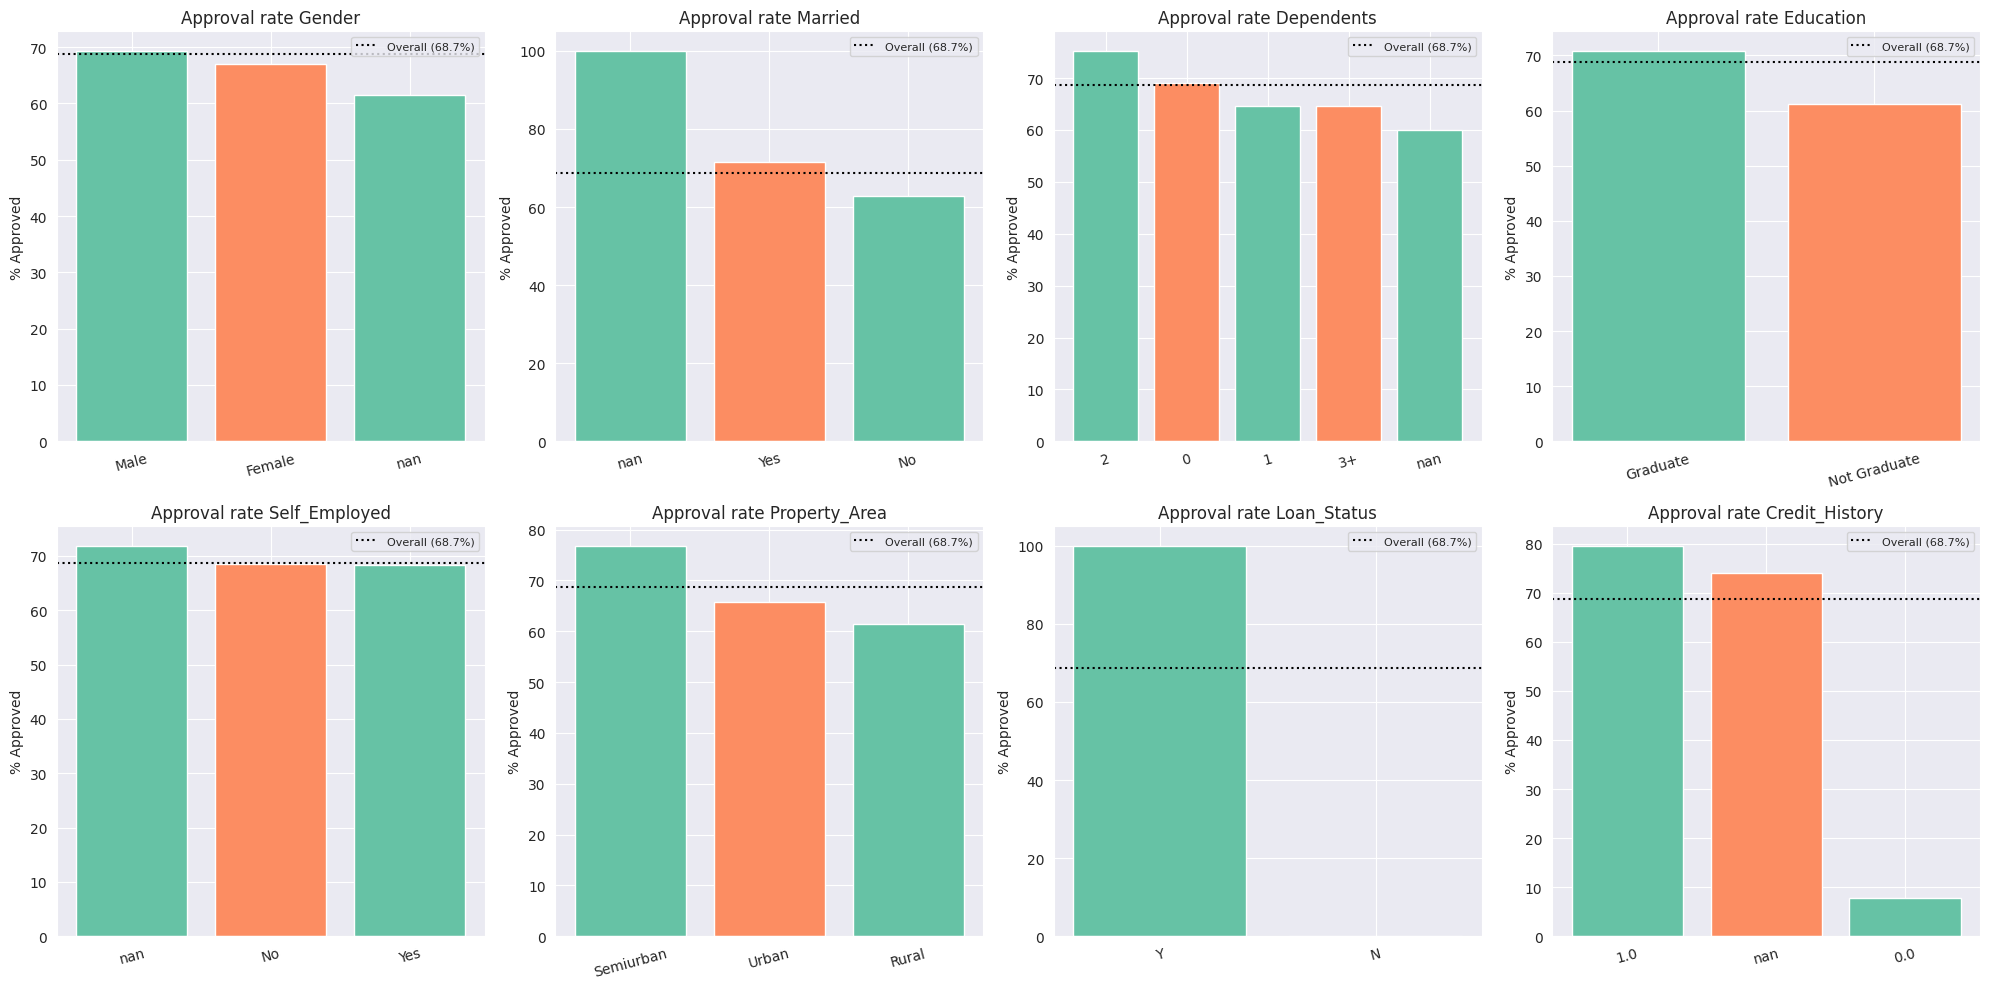

In [12]:
#Bivariate Cartegorical features
# turn Y/N into 1/0 so we can average it
loan_data['target'] = (loan_data['Loan_Status'] == 'Y').astype(int)
overall_rate = loan_data["target"].mean() * 100 # baseline: overall approval rate across everyone

fig, axes = plt.subplots(2,4, figsize=(20,10))
axes = axes.flatten()

for i,col in enumerate(cartegorical_features):
  rate = loan_data.groupby(col,dropna=False)['target'].mean().sort_values(ascending=False)*100
  label = [str(x) for x in rate.index]

  axes[i].bar(label, rate.values, color = ["#66c2a5","#fc8d62"])
  axes[i].set_title(f"Approval rate {col}")
  axes[i].axhline(overall_rate, color = 'black', linestyle = ':', label = f"Overall ({overall_rate:.1f}%)" )
  axes[i].set_ylabel('% Approved')
  axes[i].tick_params(axis='x', rotation=15)
  axes[i].legend(fontsize = 8)

for j in range(len(cartegorical_features), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

In [13]:
loan_data.dtypes

,0
Loan_ID,object
Gender,object
Married,object
Dependents,object
Education,object
Self_Employed,object
ApplicantIncome,int64
CoapplicantIncome,float64
LoanAmount,float64
Loan_Amount_Term,float64


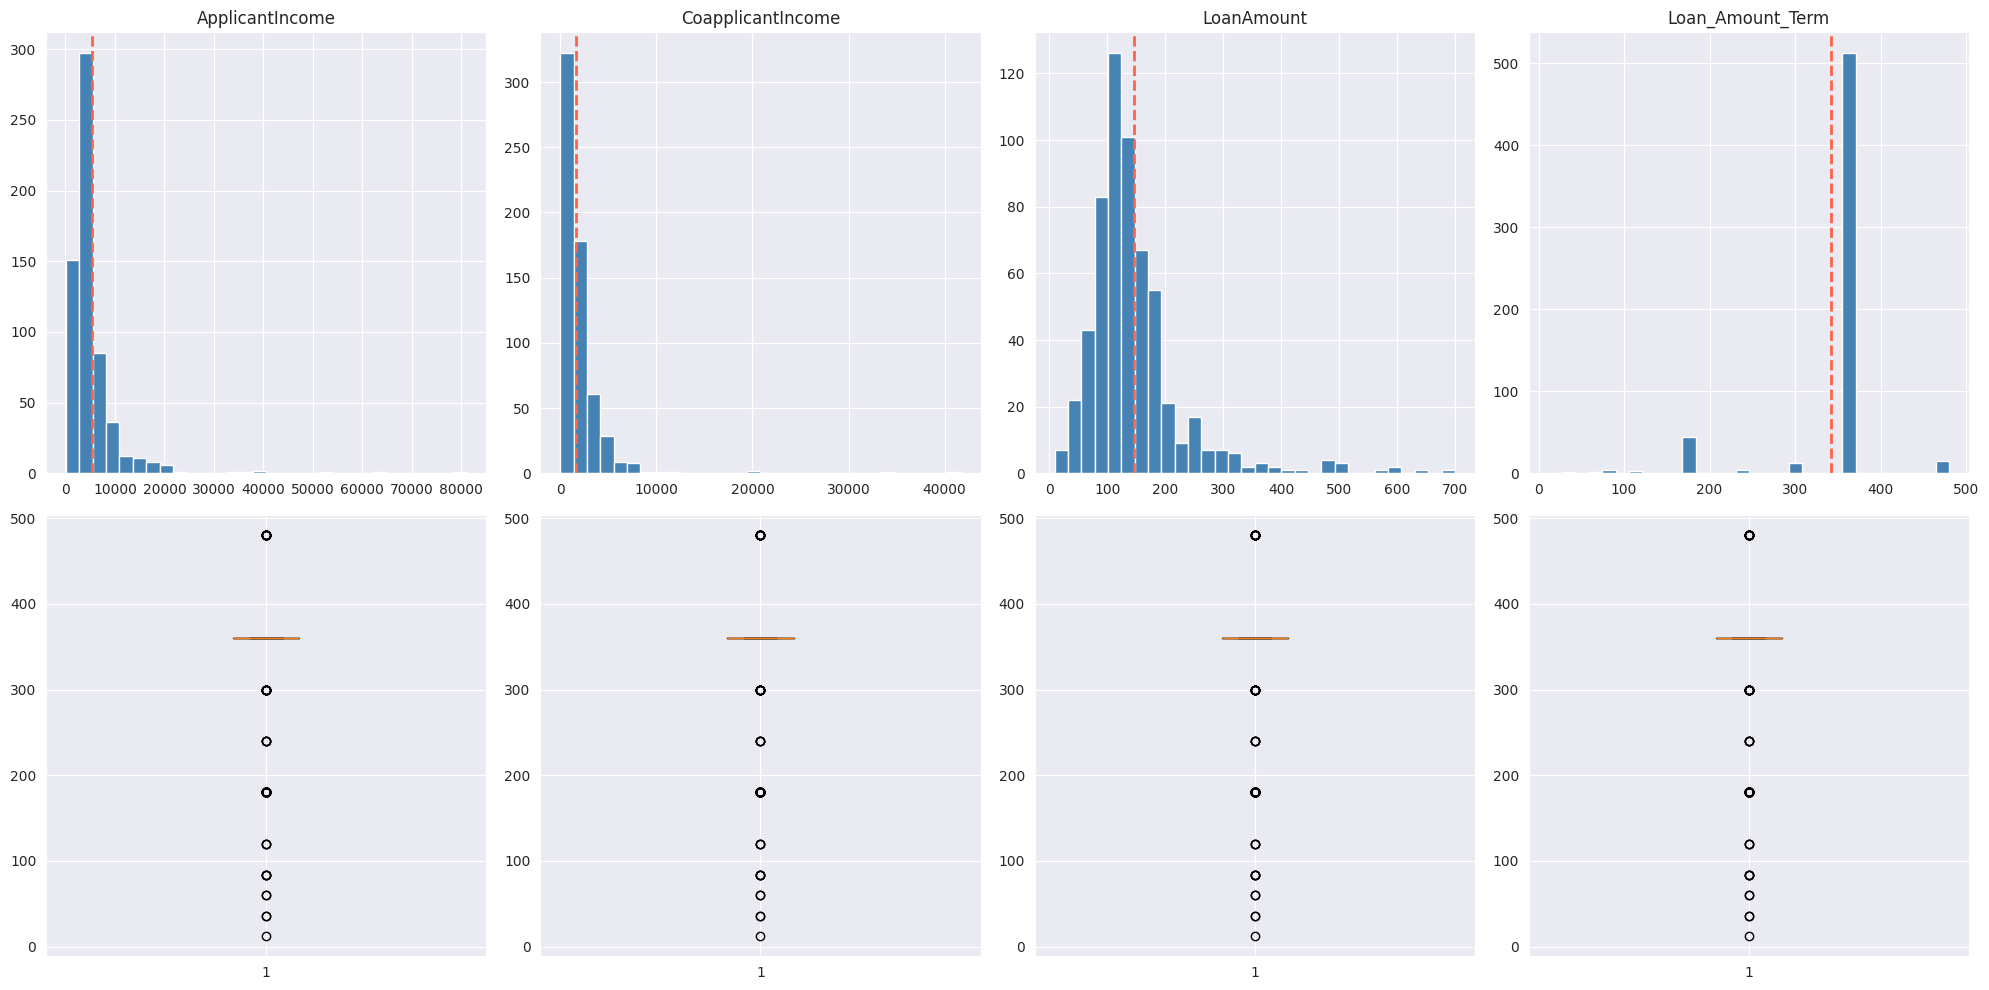

In [19]:
#Numerical Categories
#Univariate

numerical_categories = ['ApplicantIncome','CoapplicantIncome','LoanAmount','Loan_Amount_Term']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for i, col in enumerate(numerical_categories):
    data = loan_data[col].dropna()          # just this column's values, missing ones removed
    axes[0,i].hist(data, bins=30, color='steelblue')
    axes[0,i].axvline(data.mean(), color='tomato', linestyle='dashed', linewidth=2, label='Mean')
    axes[0,i].set_title(col)


for i, col in enumerate(numerical_categories):

  axes[1,i].boxplot(data)

plt.tight_layout()
plt.show()

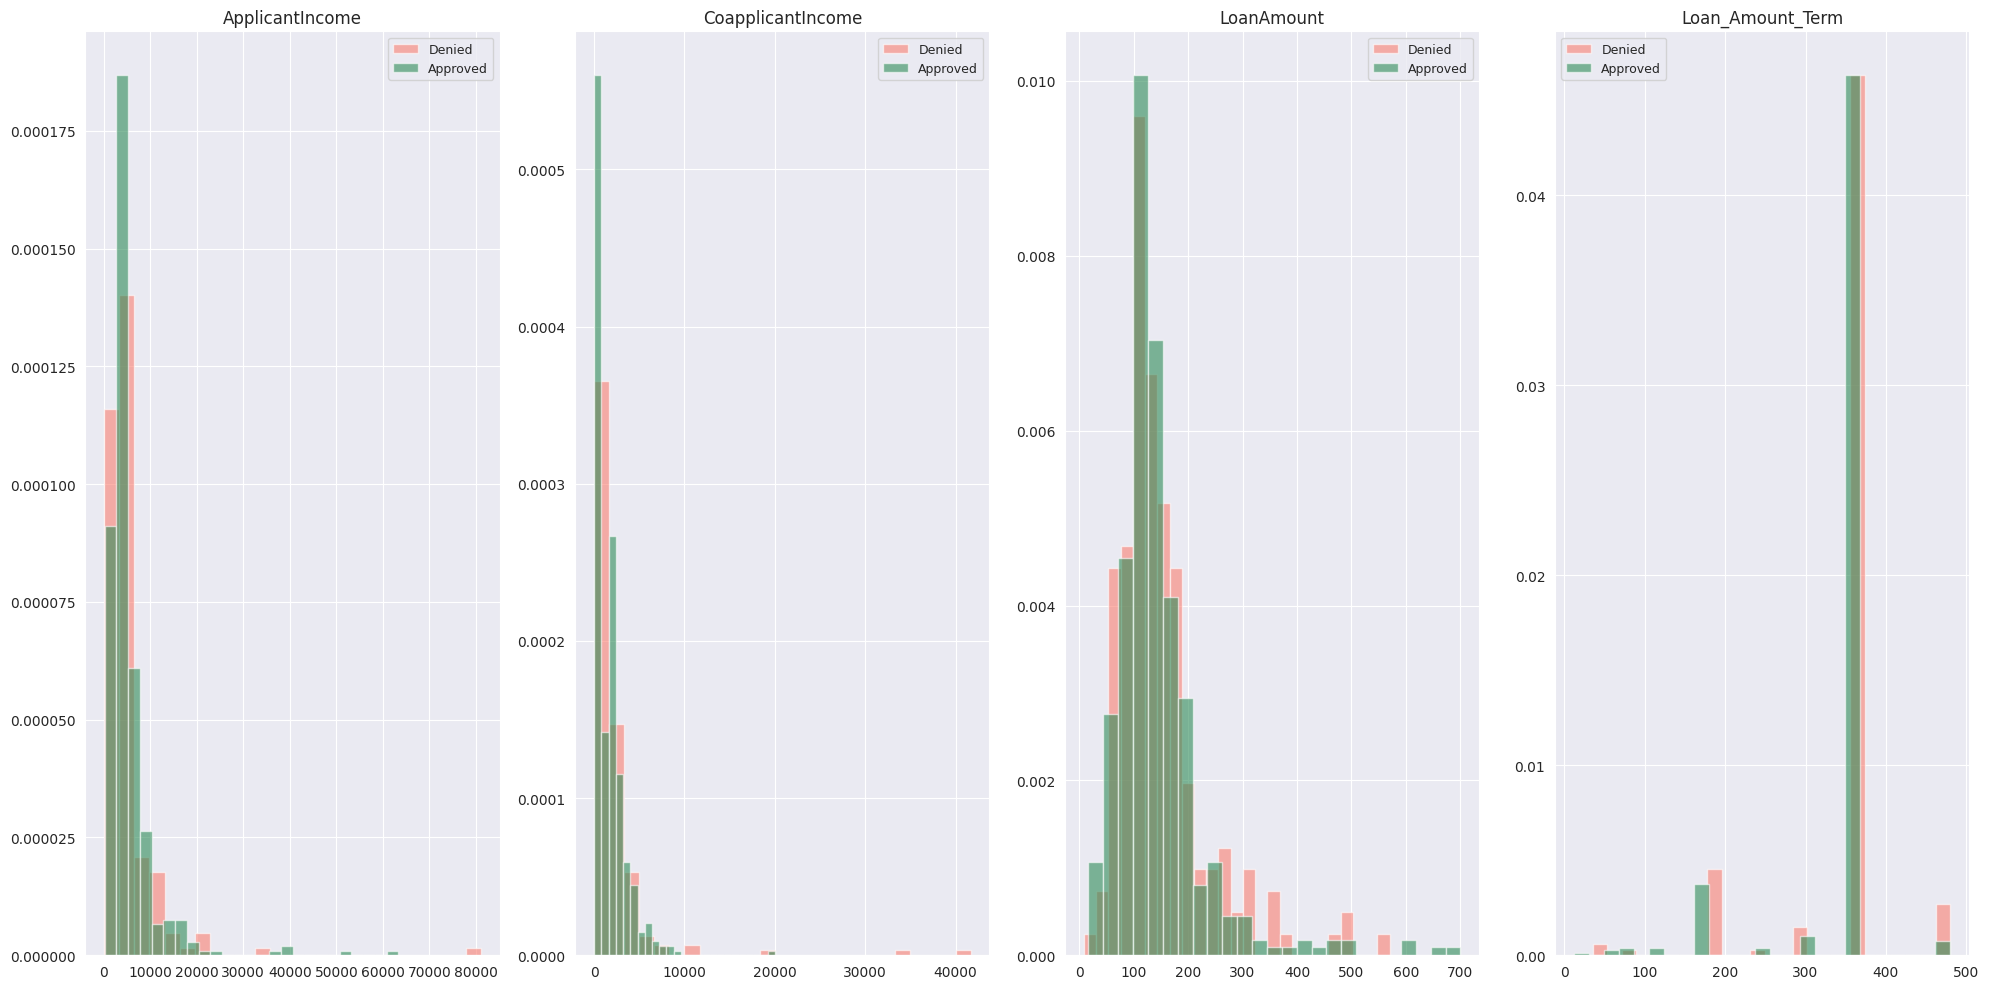

In [20]:
#Bivariate numerical values

fig, axes = plt.subplots(1,4, figsize=(20,10))

for i, col in enumerate(numerical_categories):
  for s, color, label in [(0, "salmon", "Denied"), (1, "seagreen", "Approved")]:
        sub = loan_data[loan_data["target"] == s][col].dropna()
        axes[i].hist(sub, bins=25, alpha=0.6, color=color, label=label, density=True)
        axes[i].set_title(col)
        axes[i].legend(fontsize=9)


plt.tight_layout()
plt.show()

#13. Key EDA Findings

1	Class balance: 68.7% approved vs 31.3% denied — moderately imbalanced
2	Credit_History is the dominant predictor: 79% approval when Credit_History == 1, 8% when Credit_History == 0
3	Married applicants are approved more often (71%) than singles (63%)
4	Education matters: graduates get approved more (71%) than non-graduates (61%)
5	Property_Area = Semiurban has the highest approval rate (77%) — even higher than Urban
6	Income is mildly informative: approved applicants have slightly lower mean income (5384) than denied (5446) — counterintuitive at first glance, explained by Credit_History being more important
7	6 of 12 columns have missing values (Gender, Married, Dependents, Self_Employed, LoanAmount, Loan_Amount_Term, Credit_History) — need careful imputation
8	Dependents = "3+" is a string token that needs to become 3 for numeric handling